In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader 
import torchvision.utils as vutils
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob,os,math
from tqdm import tqdm

In [2]:
!git clone https://github.com/ChinmoyGitPy/Denoising-Diffusion-Probabilistic-Model-for-generating-images-of-moon.git

Cloning into 'Denoising-Diffusion-Probabilistic-Model-for-generating-images-of-moon'...
remote: Enumerating objects: 1366, done.
remote: Counting objects: 100% (1366/1366), done.
remote: Compressing objects: 100% (1331/1331), done.
remote: Total 1366 (delta 39), reused 1359 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (1366/1366), 16.67 MiB | 33.73 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [3]:
path = glob.glob('Denoising-Diffusion-Probabilistic-Model-for-generating-images-of-moon/moon/*')

sizes = []
for p in tqdm(path[:200]):
    try:
        with Image.open(p) as img:
            sizes.append(img.size)
    except Exception as e:
        print(f"Bad file: {p} -> {e}")
print("Unique sizes:",set(sizes))

100%|██████████| 200/200 [00:00<00:00, 2101.51it/s]

Unique sizes: {(320, 297), (231, 240), (239, 232), (239, 229), (229, 240), (240, 240), (222, 240), (233, 240), (240, 221), (240, 227), (240, 224), (238, 239), (240, 230), (240, 233), (240, 239), (240, 236), (320, 296), (100, 67), (224, 240), (237, 240), (226, 240), (239, 240), (240, 231), (240, 220), (235, 239), (240, 229), (240, 223), (240, 226), (240, 235), (230, 240), (240, 238), (232, 240), (239, 239), (234, 240), (240, 219), (240, 225), (236, 240), (225, 240), (240, 228), (240, 234), (227, 240), (238, 240), (240, 237), (320, 291), (218, 240), (232, 239), (320, 294)}


In [4]:
def clean_corrupted(file_list):
    bad = []
    for p in tqdm(file_list):
        try:
            with Image.open(p) as img:
                img.verify()
        except Exception:
            bad.append(p)

    for b in bad:
        os.remove(b)
        file_list.remove(b)

    print(f"removed {len(bad)}, remaining: {len(file_list)}")
    return file_list

path = clean_corrupted(path)

100%|██████████| 1344/1344 [00:00<00:00, 5996.76it/s]

removed 0, remaining: 1344


Surprisingly enough not a single bad file!! But I manually flagged some images for removal since the dataset wasnt that big.

Found20/20 flagged files


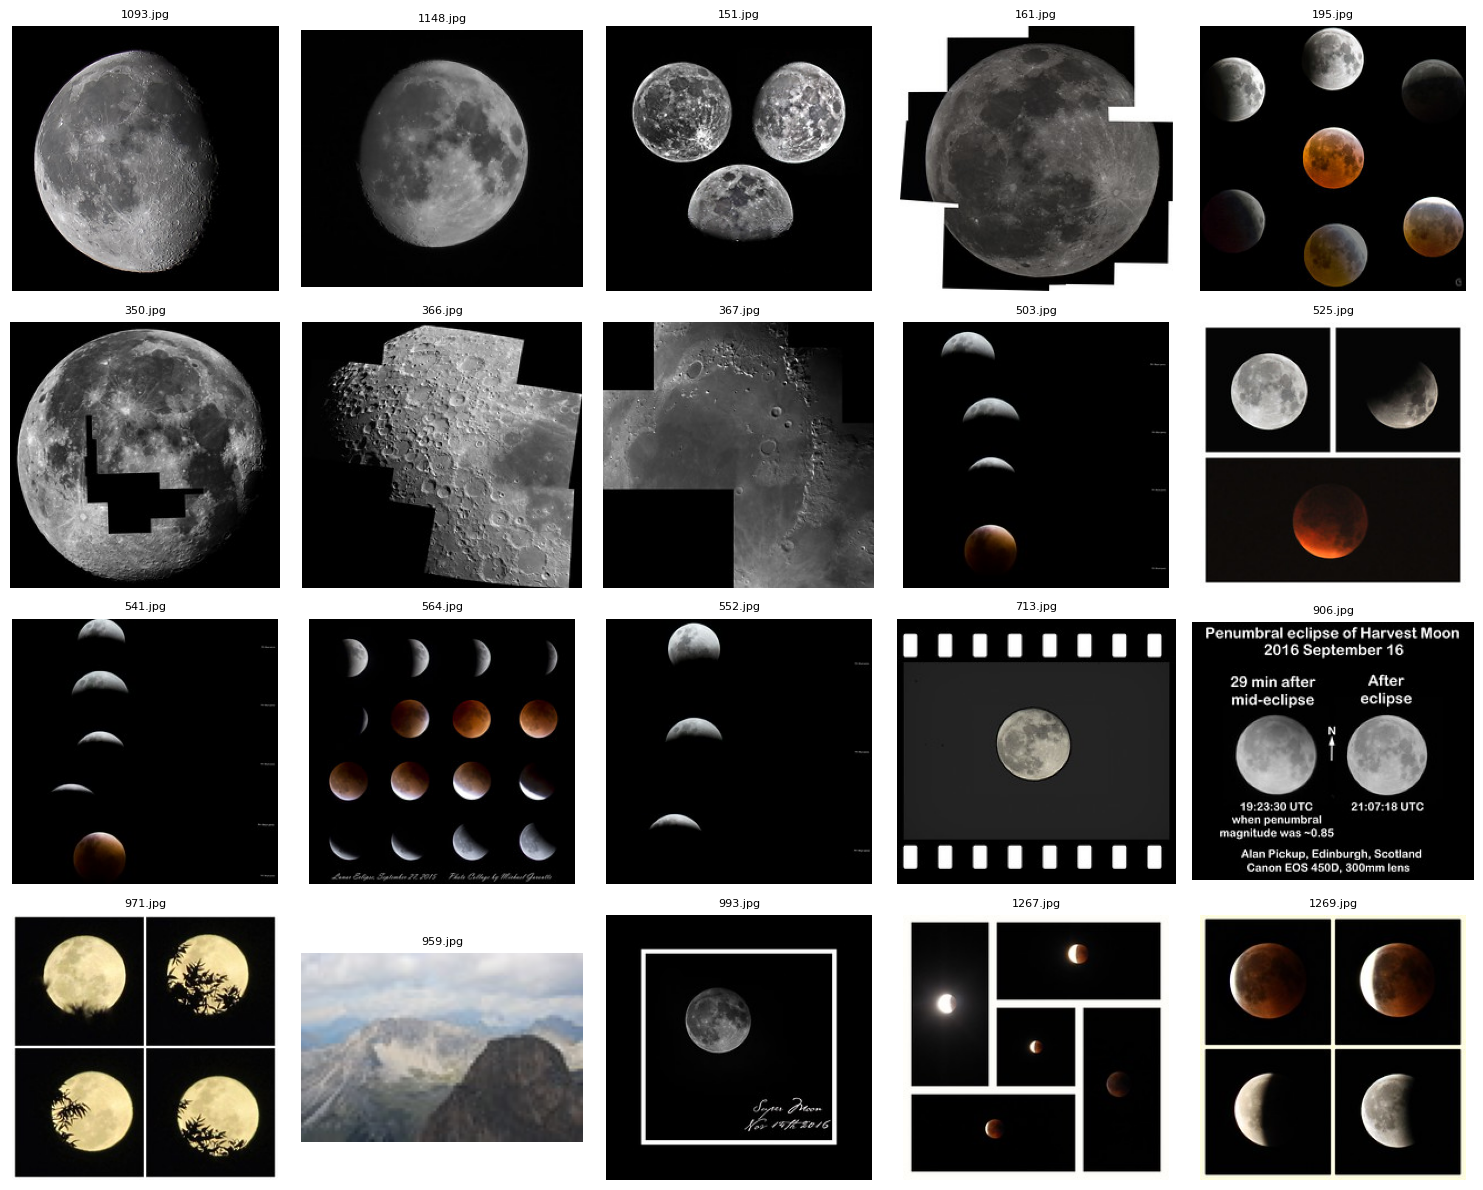

In [5]:
flagged_ids = [109,114,151,161,195,350,366,367,503,525,541,564,552,
               713,906,971,959,993,1267,1269]

def find_file(file_list,id_):
    for p in file_list:
        fname = os.path.basename(p)
        if fname == f"{id_}.jpg" or fname.startswith(f"{id_}") or f"_{id_}." in fname:
            return p
    return None

flagged_paths = []
for id_ in flagged_ids:
    fp = find_file(path,id_)
    if fp:
        flagged_paths.append(fp)
    else:
        print(f"Could not find file for {id_}")

print(f"Found{len(flagged_paths)}/{len(flagged_ids)} flagged files")

n = len(flagged_paths)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten()

for i, fp in enumerate(flagged_paths):
    img = Image.open(fp)
    axes[i].imshow(img, cmap='gray' if img.mode == 'L' else None)
    axes[i].set_title(os.path.basename(fp), fontsize=8)
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


Voila! I guess it's obvious why we must've removed these..

In [8]:
def remove_flagged(file_list,flagged_ids):
    removed = []
    remaining = []
    for p in file_list:
        fname = os.path.basename(p)
        id_ = os.path.splitext(fname)[0]
        try:
            id_num = int(id_.split('_')[-1]if '_' in id_ else int(id_))
        except ValueError:
            id_num = None

        if id_num in flagged_ids:
            removed.append(p)
        else:
            remaining.append(p)

    print(f"Flagged for removal: {len(removed)}")
    for p in removed:
        os.remove(p)
    return remaining

path = remove_flagged(path,flagged_ids)

Flagged for removal: 0


Treating as grayscale (1 channel) and image size = 64

In [9]:
out_dir = "data/moon_processed"
os.makedirs(out_dir,exist_ok=True)
IMG_SIZE = 64

def process_grayscale(file_list,out_dir,image_size=64):
    for i,p in enumerate(tqdm(file_list)):
        try:
            img = Image.open(p).convert("L")
        except Exception:
            continue
        w,h = img.size
        scale = image_size/min(w,h)
        img = img.resize((int(w*scale),int(h*scale)), Image.LANCZOS)
        w2,h2 = img.size
        left,top = (w2-image_size)//2,(h2-image_size)//2
        img = img.crop((left,top,left+image_size,top+image_size))
        img.save(os.path.join(out_dir,f"moon_{i:05d}.png"))

process_grayscale(path,out_dir,IMG_SIZE)

100%|██████████| 1324/1324 [00:02<00:00, 513.27it/s]


In [11]:
class MoonDataset(Dataset):
    def __init__(self,root_dir,image_size=64,channels=1):
        self.files = glob.glob(os.path.join(root_dir,'*.png'))
        self.channels = channels
        mean = [0.5]*channels
        std = [0.5]*channels
        self.transform = T.Compose([
            T.Resize((image_size,image_size)),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize(mean,std)
        ])
    def __len__(self):
        return len(self.files)

    def __getitem__(self,idx):
        img = Image.open(self.files[idx]).convert("L")
        return self.transform(img)

dataset = MoonDataset(out_dir,image_size=IMG_SIZE,channels=1)
dataloader = DataLoader(dataset,batch_size=64,shuffle=True,num_workers=4,pin_memory=True,drop_last=True)
batch = next(iter(dataloader))
print(batch.shape,batch.min().item(),batch.max().item())

torch.Size([64, 1, 64, 64]) -1.0 1.0


Now I'm gonna check the images again after grayscaling, cropping, normalising for a quick sanity check that what the model will see..

Batch Shape: torch.Size([64, 1, 64, 64])
Value range: <built-in method item of Tensor object at 0x7ec3602fb2a0> to 1.0


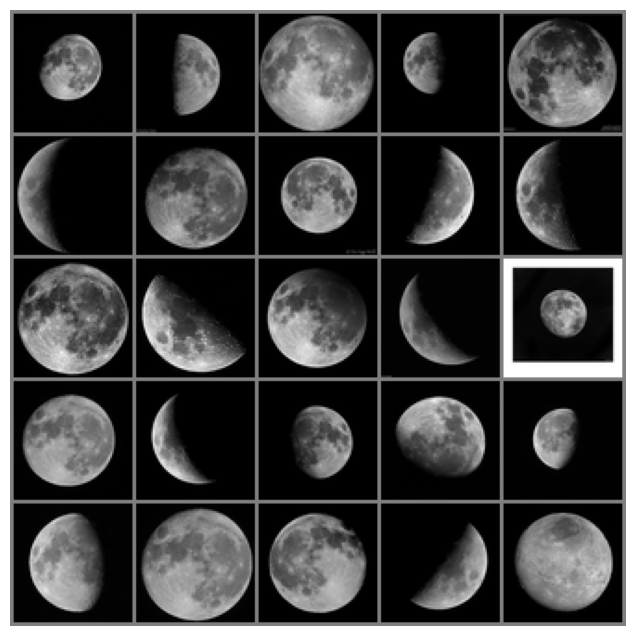

In [12]:
batch = next(iter(dataloader))
print("Batch Shape:", batch.shape)
print("Value range:",batch.min().item,"to",batch.max().item())

grid = vutils.make_grid(batch[:25],nrow=5,normalize=False)
grid_display = (grid+1)/2

plt.figure(figsize=(8,8))
plt.imshow(grid_display.permute(1,2,0).squeeze(),cmap='gray')
plt.axis('off')
plt.show()

Nice, as expected. Next we're moving to noise scheduiling..

In [13]:
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start,end,timesteps)

def cosine_beta_schedule(timesteps,s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0,timesteps,steps)
    alphas_cumprod = torch.cos(((x/timesteps)+s)/(1+s)*math.pi*0.5)**2
    alphas_cumprod = alphas_cumprod/alphas_cumprod[0]
    betas = 1-(alphas_cumprod[1:]/alphas_cumprod[:-1])
    return torch.clip(betas,0.0001,0.9999)

def get_index_from_list(vals,t,x_shape):
    batch_size = t.shape[0]
    out = vals.gather(-1,t.cpu())
    return out.reshape(batch_size,*((1,)*(len(x_shape)-1))).to(t.device)

def forward_diffusion_sample(x_0,t,device="cpu"):
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod,t,x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod,t,x_0.shape
    )
    return sqrt_alphas_cumprod_t.to(device)*x_0.to(device)\
    +sqrt_one_minus_alphas_cumprod_t.to(device)*noise.to(device),noise.to(device)

T_STEPS = 150
SCHEDULE = "cosine"
if SCHEDULE == "cosine":
    betas = cosine_beta_schedule(timesteps=T_STEPS)
else:
    betas = linear_beta_schedule(timesteps=T_STEPS)

alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas,axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1],(1,0),value=1.0)
sqrt_recip_alias = torch.sqrt(1.0/alphas)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.-alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev)/(1.-alphas_cumprod)


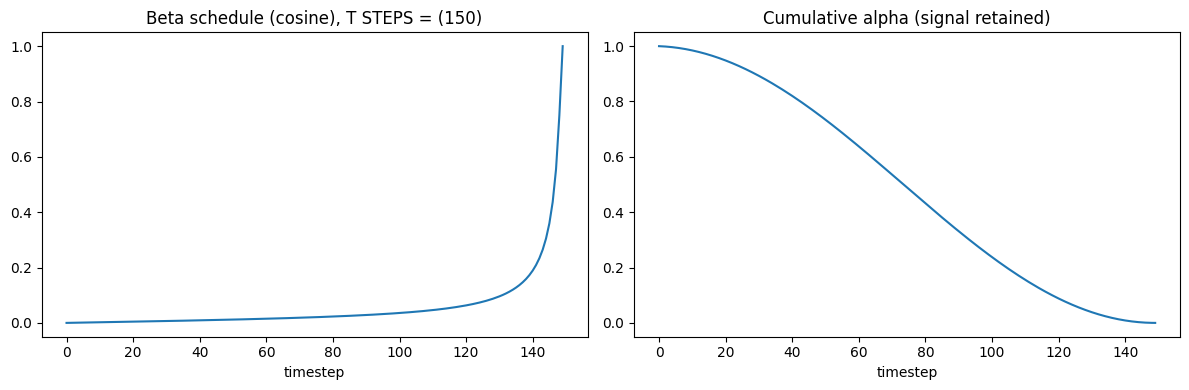

In [14]:
fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(betas.numpy())
axes[0].set_title(f"Beta schedule ({SCHEDULE}), T STEPS = ({T_STEPS})")
axes[0].set_xlabel("timestep")

axes[1].plot(alphas_cumprod.numpy())
axes[1].set_title("Cumulative alpha (signal retained)")
axes[1].set_xlabel("timestep")

plt.tight_layout()
plt.show()

In [15]:
def show_tensor_image(image):
    reverse_transforms = T.Compose([
        T.Lambda(lambda t: (t+1)/2),
        T.Lambda(lambda t: t.clamp(0,1)),
        T.Lambda(lambda t: t.permute(1,2,0)),
        T.Lambda(lambda t: t* 255.),
        T.Lambda(lambda t: t.numpy().astype(np.uint8)),
        T.Lambda(lambda t: t.squeeze(-1) if t.shape[-1]==1 else t),
        T.ToPILImage(),
    ])
    if len(image.shape) == 4:
        image = image[0,:,:,:]
    plt.imshow(reverse_transforms(image.cpu()),cmap="gray")

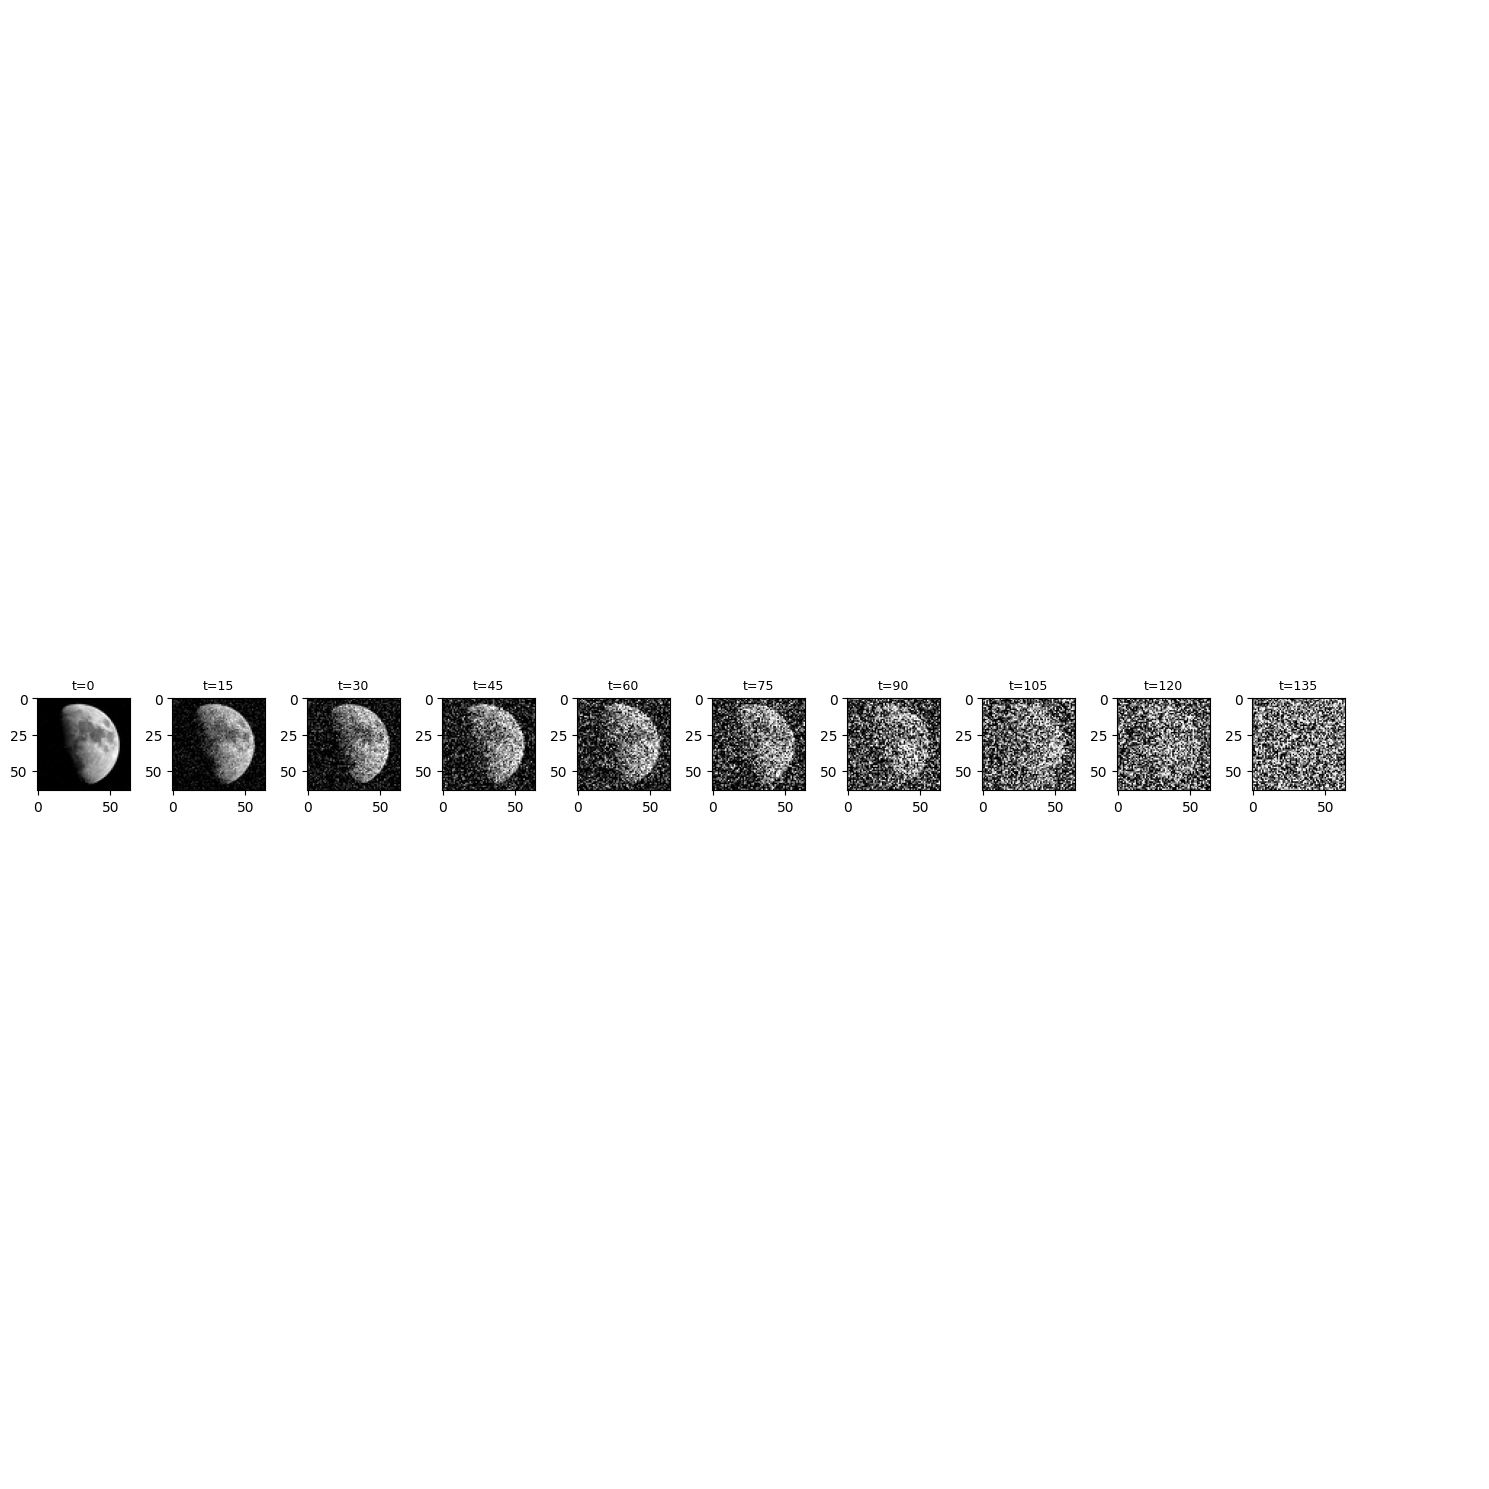

In [16]:
image = next(iter(dataloader))[0]

plt.figure(figsize=(15,15))
plt.axis('off')
num_images = 10
stepsize = int(T_STEPS/num_images)

for idx in range(0,T_STEPS,stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
    plt.subplot(1,num_images + 1, int(idx/stepsize)+1)
    img,noise = forward_diffusion_sample(image,t)
    show_tensor_image(img)
    plt.title(f"t={idx}",fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False, groups=8):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

        if up:
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
            self.res_proj = nn.Conv2d(2 * in_ch, out_ch, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
            self.res_proj = nn.Conv2d(in_ch, out_ch, 1)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.act = nn.SiLU()

    def forward(self, x, t):
        residual = self.res_proj(x)

        h = self.norm1(self.act(self.conv1(x)))
        time_emb = self.act(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.norm2(self.act(self.conv2(h)))

        h = h + residual
        return self.transform(h)


class SelfAttention(nn.Module):
    def __init__(self, channels, groups=8):
        super().__init__()
        self.norm = nn.GroupNorm(groups, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        self.scale = channels ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]

        attn = torch.softmax((q.transpose(1, 2) @ k) * self.scale, dim=-1)
        out = v @ attn.transpose(1, 2)
        out = out.reshape(B, C, H, W)
        return x + self.proj(out)


class MoonUnet(nn.Module):
    def __init__(self, image_channels=1, time_emb_dim=64):
        super().__init__()
        down_channels = (32, 64, 128, 256)
        up_channels = (256, 128, 64, 32)
        out_dim = image_channels

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )

        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i + 1], time_emb_dim)
            for i in range(len(down_channels) - 1)
        ])

        self.bottleneck_attn = SelfAttention(down_channels[-1])

        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i + 1], time_emb_dim, up=True)
            for i in range(len(up_channels) - 1)
        ])

        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        x = self.conv0(x)

        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)

        x = self.bottleneck_attn(x)

        for up in self.ups:
            residual_x = residual_inputs.pop()
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)

        return self.output(x)


model = MoonUnet()
print("Num params:", sum(p.numel() for p in model.parameters()))
model


Num params: 4295489


MoonUnet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): SiLU()
  )
  (conv0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): Block(
      (time_mlp): Linear(in_features=64, out_features=64, bias=True)
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transform): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (res_proj): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act): SiLU()
    )
    (1): Block(
      (time_mlp): Linear(in_features=64, out_features=128, bias=True)
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transform): Conv2d(128, 128, ker

In [ ]:
@torch.no_grad()
def sample_timestep(model,x,t):
    betas_t = get_index_from_list(betas,t,x.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod,t,x.shape)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod,t,x.shape)
    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alias,t,x.shape)

    pred_noise = model(x,t)

    x0_pred = (x - sqrt_one_minus_alphas_cumprod_t*pred_noise)/sqrt_one_minus_alphas_cumprod_t
    x0_pred = torch.clamp(x0_pred,-1.0,1.0)

    pred_noise = (x - sqrt_alphas_cumprod_t*x0_pred)/sqrt_one_minus_alphas_cumprod_t

    model_mean = sqrt_recip_alphas_t * (x - betas_t*pred_noise/sqrt_one_minus_alphas_cumprod_t)

    posterior_variance_t = get_index_from_list(posterior_variance,t,x.shape)
    if t[0] == 0:
        return model_mean
    return model_mean + torch.sqrt(posterior_variance_t)*noise


@torch.no_grad()
def sample_plot_image(model,n=6):
    img = torch.randn((n,1,64,64),device="cuda")
    for i in range(0,T_STEPS)[::-1]:
        t = torch.full((n,),i,device="cuda",dtype=torch.long)
        img = sample_timestep(model,img,t)

    fig,axes = plt.subplots(1,n,figsize=(2*n,2))
    for k in range(n):
        show_tensor_image(img[k].unsqueeze(0))
        axes[k].axis('off') if hasattr(axes,'__len__') else None
    plt.tight_layout()
    plt.show()
    

In [ ]:
device = "cuda"

def get_loss(model,x_0,t,device="cpu"):
    x_noisy,noise = forward_diffusion_sample(x_0,t,device)
    noise_pred = model(x_noisy,t)
    return F.l1_loss(noise,noise_pred)

model = MoonUnet().to("cuda")
optimizer = Adam(model.parameters(),lr=1e-4)

BATCH_SIZE = 128
epochs = 500

dataloader = DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=2,pin_memory=True,drop_last=True)

losses = []
best_loss = float('inf')

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in dataloader:
        optimizer.zero_grad()
        t = torch.randint(0,T_STEPS,(batch.shape[0],),device=device).long()
        loss = get_loss(model,batch.to(device),t,device)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss/len(dataloader)
    losses.append(avg_loss)
    print(f"Epoch {epoch:03d}|Loss:{avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(),"best_checkpoint.pt")

    if epoch % 25 == 0 or epoch == epochs -1:
        sample_plot_image(model)
